# Segmentation of the problem /area 
Segmentation of the area into components consisting of inaccessible patches + their accessible neighbors

**Steps to create the segments**
1. dissolve component stands into one big geometry
2. find the "ring of (already fully accessible) neighbors" of the component
    together, this will be one problem area (component and neighbors). then the next steps are to define the exit points to public road
3. merge component and neighbors to create basis for future road network

## Imports & Settings

### 📦 Library imports

In [1]:
## Standard library imports
import os
import re
import json
import csv
import random
from collections import Counter, defaultdict

# Third-party libraries
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import Delaunay

# Geospatial processing
from shapely.ops import unary_union, nearest_points, snap
from shapely.geometry import shape, Polygon, MultiPolygon, LineString, Point, MultiPoint

# Graph processing
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import matplotlib.patheffects as path_effects
from shapely.geometry import box  # <- correct import for box

import itertools
import warnings

### ⚙️ Global settings

In [2]:
# Set global defaults
plt.rcParams.update({
    'axes.labelsize': 0,  # Remove axis labels
    'axes.titlesize': 0,  # Remove title size
    'axes.linewidth': 0,  # Remove axis borders
    'axes.grid': False,  # Disable grid
    'xtick.bottom': False,  # Disable x-axis ticks
    'ytick.left': False,  # Disable y-axis ticks
    'xtick.labelsize': 0,  # Hide x-axis labels
    'ytick.labelsize': 0,  # Hide y-axis labels
    'axes.spines.top': False,  # Remove top axis border
    'axes.spines.right': False,  # Remove right axis border
    'axes.spines.left': False,  # Remove left axis border
    'axes.spines.bottom': False  # Remove bottom axis border
})


## 📂 Load data

### 🌲 load stands 

In [3]:
# Define path
#shapefile = r"1_Preprocessed_Data\0_Forest_Management_Units_manuallycleaned\fixed_snapped_opt1-1m-manually-cleaned.shp"
#shapefile = r"1_Preprocessed_Data\0_Forest_Management_Units_manuallycleaned\CasteloPaiva_clean.shp"
shapefile = r"1_Preprocessed_Data\1_Stand_Accessibility\stands.shp"

# Load shapefile
stands_gdf = gpd.read_file(shapefile)
#.assign(geometry=lambda df: df.geometry.buffer(0))
print(f"{len(stands_gdf)} stands in total")

687 stands in total


In [4]:
stands_gdf.head(1)

,OBJECTID,TARGET_FID,LandUse_1,Ocupacao,ID_UG,NOME,YY_correct,XX_Correct,Altitude,Declive,...,Hectares,UsoSolo20,Shape_Leng,Shape_Area,HBC,CH,CBD,CC,road_acces,geometry
0,127,757,1,EcPb_3_9_3_Pv,836,Castelo de Paiva,154379.276963,-9216.013743,177.0,16.8833,...,15.015687,Eucalipto,2215.335044,150156.870494,2.9,0.0,0.0,0.0,full,"POLYGON ((-8904.284 154402.877, -8864.968 1543..."


In [5]:
# subset the 3 different stand access types
accessible_stands_gdf = stands_gdf[stands_gdf['road_acces'] == 'full'].copy()
timberroad_stands_gdf = stands_gdf[stands_gdf['road_acces'] == 'timber'].copy()
inaccessible_stands_gdf = stands_gdf[stands_gdf['road_acces'] == 'none'].copy()

# Optional: print counts to verify
print(f"{len(accessible_stands_gdf)} fully accessible stands")
print(f"{len(timberroad_stands_gdf)} timber road only stands")
print(f"{len(inaccessible_stands_gdf)} inaccessible stands")


203 fully accessible stands
169 timber road only stands
315 inaccessible stands


#### 👁 visualize for verification

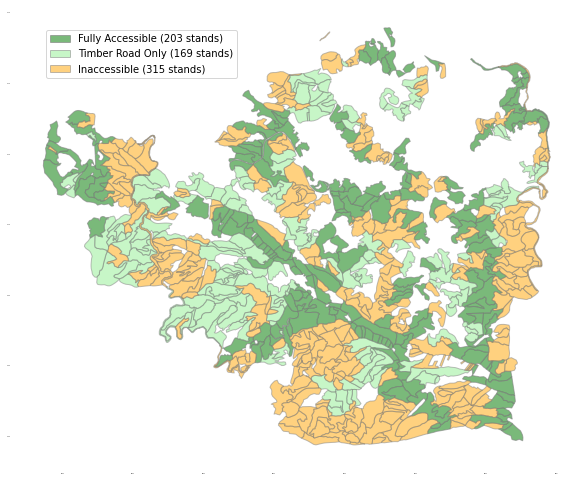

In [6]:
# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each category of stands explicitly
accessible_stands_gdf.plot(ax=ax, color='forestgreen', edgecolor='grey', label=f'Fully Accessible ({len(accessible_stands_gdf)} stands)', alpha=0.6)
timberroad_stands_gdf.plot(ax=ax, color='lightgreen', edgecolor='grey', label=f'Timber Road Only ({len(timberroad_stands_gdf)} stands)', alpha=0.5)
inaccessible_stands_gdf.plot(ax=ax, color='orange', edgecolor='grey', label=f'Inaccessible ({len(inaccessible_stands_gdf)} stands)', alpha=0.5)

# Create custom legend with explicit labels
legend_labels = [
    Patch(facecolor='forestgreen', edgecolor='grey', label=f'Fully Accessible ({len(accessible_stands_gdf)} stands)', alpha=0.6),
    Patch(facecolor='lightgreen', edgecolor='grey', label=f'Timber Road Only ({len(timberroad_stands_gdf)} stands)', alpha=0.5),
    Patch(facecolor='orange', edgecolor='grey', label=f'Inaccessible ({len(inaccessible_stands_gdf)} stands)', alpha=0.5)
]

# Add legend to the plot with modified position (bottom left corner)
ax.legend(handles=legend_labels, bbox_to_anchor=(0.05, 0.95), loc='upper left', borderaxespad=0.)

# Display the plot
plt.show()


### 🛤️ load road data (timber roads)

#### 🛣️🛤️ timber roads

In [7]:
# Load the suitable roads
roads_min3m = gpd.read_file(r"1_Preprocessed_Data/1_Roads_clean/roads_min_3m.shp")

# Check CRS alignment for roads (optional)
print(f"CRS of roads: {roads_min3m.crs}")

# Print the number of roads loaded and preview the first row
print(f"{len(roads_min3m)} usable roads loaded")
roads_min3m.head(1)

CRS of roads: PROJCRS["ETRS89 / Portugal TM06",BASEGEOGCRS["ETRS89",DATUM["European Terrestrial Reference System 1989",ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]],ID["EPSG",6258]],PRIMEM["Greenwich",0,ANGLEUNIT["Degree",0.0174532925199433]]],CONVERSION["unnamed",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",39.6682583333333,ANGLEUNIT["Degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-8.13310833333333,ANGLEUNIT["Degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",1,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",0,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,3],AXIS["(E)",east,ORDER[1],LENGTHUNIT["metre",1,ID["EPSG",9001]]],AXIS["(N)",north,ORDER[2],LENGTHUNIT["metre",1,ID["EPSG",9001]]],AXIS["ellipsoidal height (h)",up,ORDER[3],LENGTHUNIT["metre",1,ID["EPSG",9001]]

,Id,ID_RV,DATA_ACCAO,COD_INE,DESIGNACAO,OPERAC,REDE_DFCI,TIPO_PISO,COMPRIM,LARGURA,...,FASE_2017,TIPO_VEICU,INTER_2018,EXEC_2018,FIN_2018,FASE_2018,OBSERV,LARGURA_ZE,ROADWIDTH,geometry
0,1,1,2011-01-31,10609,VARIANTE EN222,OPER,1,A,1398.32,0.0,...,0,VTTR,ESI,0,0,0,NaN,1,6.0,"LINESTRING (-11588.474 151775.913, -11614.929 ..."


### (🌊 load river data) - irrelevant

In [8]:
# Load the rivers GeoDataFrame from a GeoPackage file
rivers_gdf = gpd.read_file(r'Bonus_Materials\Selected_subset\Rivers_CDP.gpkg')

# Align the CRS of the rivers GeoDataFrame to match the CRS of allstands_gdf
rivers_gdf = rivers_gdf.to_crs(stands_gdf.crs)

# Print the number of rows in the rivers GeoDataFrame
print(f"{len(rivers_gdf)} rivers loaded")

# Display the first row of the rivers GeoDataFrame
rivers_gdf.head(1)

59 rivers loaded


c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\io\file.py:350: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")
c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\io\file.py:350: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")
c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\io\file.py:350: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


,OBJECTID,DFDD,RN_I_ID,REX,HYP,LOC,FUN,NVS,LENGTH,TR,...,TNODE,STRAHLER,nameTxtInt,nameText,NEXTUPID,NEXTDOWNID,FNODE,CatchID,PFAFSTETTER,geometry
0,4405,BH140,NaN,PT,1.0,44.0,6.0,5.0,4416.72998,NA,...,NO15004431,1.0,NaN,NaN,NaN,RL15004502,NO15004430,226,NaN,MULTILINESTRING Z ((-12976.644 142597.803 312....


<AxesSubplot: >

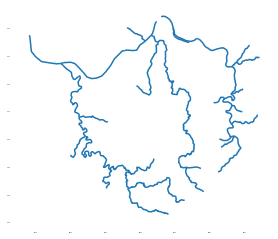

In [9]:
rivers_gdf.geometry.plot()

In [10]:
#check crs
rivers_gdf.crs

<Projected CRS: PROJCRS["ETRS89 / Portugal TM06",BASEGEOGCRS["ETRS ...>
Name: ETRS89 / Portugal TM06
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## basic data preps

#### geometry types

In [11]:
# unique geometry types
unique_geom_types = stands_gdf.geom_type.unique()
print("Unique Geometry Types:", unique_geom_types)

Unique Geometry Types: ['Polygon']


#### check for overlaps

No overlaps found.


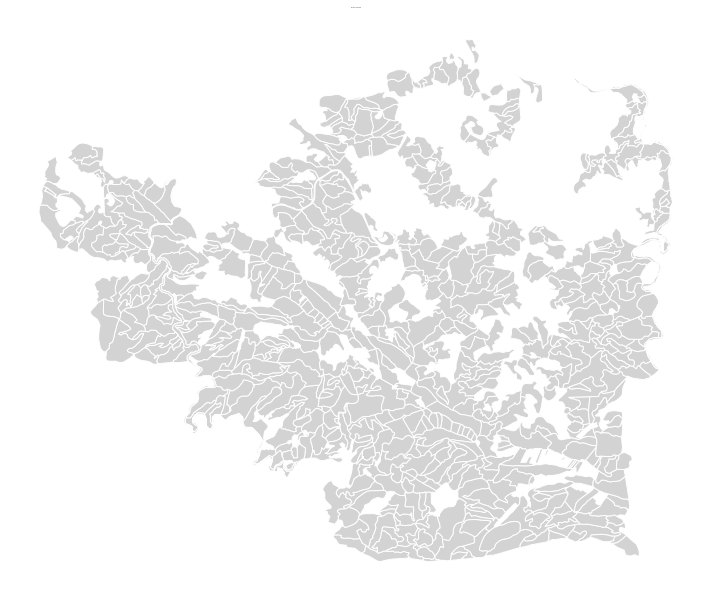

In [12]:
# Add an ID column to identify stands
stands = stands_gdf.reset_index().rename(columns={'index': 'stand_id'})

# Overlay stands with themselves
overlaps = stands.overlay(stands, how="intersection", keep_geom_type=False)

# Exclude self-intersections: keep only where stand_id differs
overlaps = overlaps[overlaps['stand_id_1'] != overlaps['stand_id_2']]

# Remove zero-area geometries
overlaps = overlaps[overlaps.geometry.area > 0]

# Plot original stands in light gray
ax = stands.plot(color='lightgray', edgecolor='white', figsize=(10, 10))

if not overlaps.empty:
    print("Overlapping areas detected.")
    overlaps.plot(ax=ax, color='red', edgecolor='black', alpha=0.7)
    plt.title("Detected Overlapping Areas")
else:
    print("No overlaps found.")
    plt.title("No Overlaps Found")

plt.axis('off')
plt.tight_layout()
plt.show()


#### check for gaps

In [13]:
# Create a union of all geometries to check for gaps
union_geom = stands_gdf.unary_union

# Find gaps by subtracting the union from the total bounding box
bounding_box = Polygon.from_bounds(*stands_gdf.total_bounds)
gaps = bounding_box.difference(union_geom)

# Check if gaps exist
if gaps.is_empty:
    print("No gaps detected.")
else:
    print("Gaps found in the dataset.")


Gaps found in the dataset.


Since I manually cleaned the stands data before, all gaps that are found are actual openings in the forest area, so all good here. Nothing more to correct.

## 🏝️ Identify "islands" (patches of inaccessible stands)

We have a couple of forest stand "islands", which are patches of stands that are separated from each other by areas that are already accessible.

This segmentation of the study area allows to "split"" original problem into smaller problems, that can be solved seperately, which improves runtime etc.

Let's identify those "patches" / segments:

### model inaccessible stands as graph
- Take all stands that are not connected to roads yet.

- Treat each stand as a node and create edges between stands that are touching (intersecting geometrically).

- use a 1m buffer when looking for neighboring stands when creating the graph

In [14]:
out_path = r"1_Preprocessed_Data\3_Stand_Components"
os.makedirs(out_path, exist_ok=True)

In [15]:
# Initialize an empty undirected graph
G = nx.Graph()

stands = inaccessible_stands_gdf.copy()

# Apply a 1-meter buffer to each stand geometry and store it in the GeoDataFrame
stands['buffered_geometry'] = stands['geometry'].buffer(1.0)  # 1-meter buffer

# Add nodes to the graph using 'ID_UG' as the node label and buffered geometry
for _, row in stands.iterrows():
    G.add_node(row['ID_UG'], geometry=row['buffered_geometry'])

# Create edges between stands whose buffered geometries intersect
for (i, row_i), (j, row_j) in itertools.combinations(stands.iterrows(), 2):
    if row_i['buffered_geometry'].intersects(row_j['buffered_geometry']):
        G.add_edge(row_i['ID_UG'], row_j['ID_UG'])

# Remove the temporary buffered geometry column (optional)
stands = stands.drop(columns=['buffered_geometry'])

print('Graph created ( with 1-meter buffer) around each stand.')

# verify
num_nodes = G.number_of_nodes()
print('Nodes:', num_nodes,)

Graph created ( with 1-meter buffer) around each stand.
Nodes: 315


### 👁 visualize graph of inaccessible stands

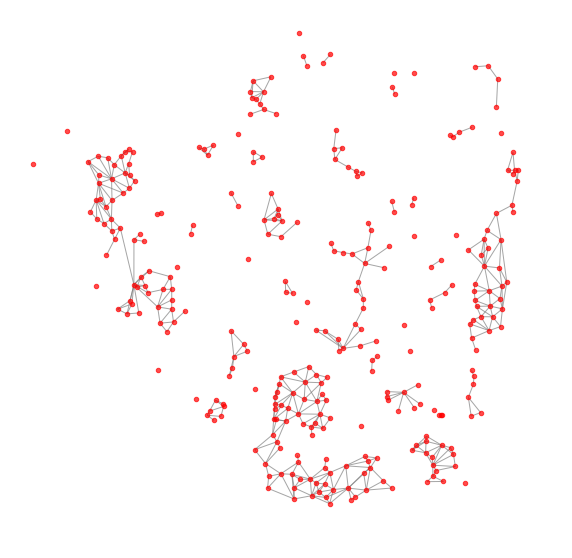

In [16]:
# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Get positions of nodes based on the centroid of each stand's geometry
pos = {node: (stand['geometry'].centroid.x, stand['geometry'].centroid.y) 
       for node, stand in G.nodes(data=True)}

# Draw the graph with some enhanced styling
nx.draw(G, pos, ax=ax, with_labels=False, node_size=20, node_color='red', 
        font_size=8, font_color='black', alpha=0.7, edge_color='gray')

# Save and display the plot
plt.savefig(f"{out_path}/graph_of_inaccessible_stands.png")
plt.show()

### ✅ validate if the created graph lies within the boundaries of the inaccessible stands

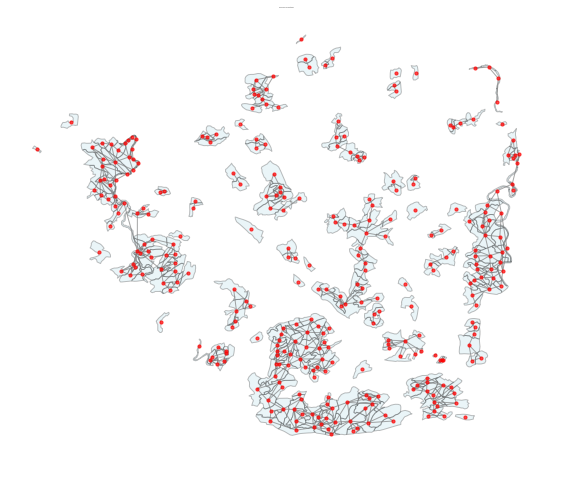

In [17]:
# doublecheck with geometries
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the geometries of the stands
stands.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.25)

# Get node positions based on the centroid of each stand geometry
pos = {node: (stand['geometry'].centroid.x, stand['geometry'].centroid.y) 
       for node, stand in G.nodes(data=True)}

# Draw the graph nodes and edges
nx.draw(G, pos, ax=ax, with_labels=False, node_size=10, node_color='red', 
        font_size=8, font_color='black', alpha=0.7, edge_color='gray')

plt.title("Graph of Inaccessible stands")

# Save and show the plot
plt.savefig(f"{out_path}/inaccessible_components_with_graph.png")
plt.show()

### 👁 visualize with roads

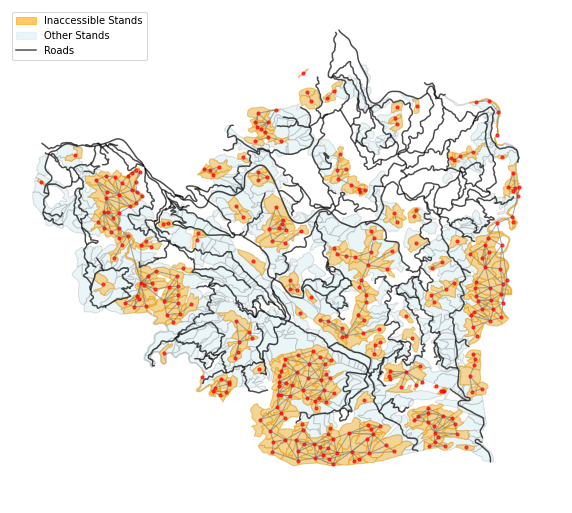

In [18]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the roads
roads_min3m.plot(ax=ax, color='black', alpha=0.7)

# Plot the other stands
stands_gdf.plot(ax=ax, color='lightblue', edgecolor='grey', alpha=0.25)

# Plot the geometries of the stands
stands.plot(ax=ax, color='orange', edgecolor='orange', alpha=0.4)

# Get node positions based on the centroid of each stand geometry
pos = {node: (stand['geometry'].centroid.x, stand['geometry'].centroid.y) 
       for node, stand in G.nodes(data=True)}

# Draw the graph nodes and edges
nx.draw(G, pos, ax=ax, with_labels=False, node_size=10, node_color='red', 
        font_size=8, font_color='black', alpha=0.7, edge_color='gray')

# Create legend handles with matching alpha
orange_patch = mpatches.Patch(color='orange', alpha=0.6, label='Inaccessible Stands')
blue_patch = mpatches.Patch(color='lightblue', alpha=0.25, label='Other Stands')
black_line = mlines.Line2D([], [], color='black', alpha=0.7, label='Roads')

# Add legend to the plot
ax.legend(handles=[orange_patch, blue_patch, black_line], loc='upper left')

# Save and show the plot
plt.savefig(f"{out_path}/inaccessible_components_with_graph_with_roads_with_allstands.png")
plt.show()


### 🔎 identify connected components

In [19]:
connected_components = list(nx.connected_components(G))  # List of sets of connected nodes

# Create a dictionary where the key is the component index (starting from 1) and the value is the set of nodes in that component
components_dict = {i+1: component for i, component in enumerate(connected_components)}

print('Connected components (= Inaccessible "patches"):', len(components_dict))

Connected components (= Inaccessible "patches"): 51


In [20]:
# Print the dictionary of components
for c_id, component in components_dict.items():
    print(f"Component {c_id}: {component}")

Component 1: {838}
Component 2: {1537, 1415, 907, 908, 909, 910, 1163, 912, 913, 914, 1167, 1557, 1558, 1559, 1561, 1562, 1563, 1565, 1566, 1319, 1323, 1580, 1581, 1582, 1583, 1584, 1328, 1329, 1330, 1331, 1333, 1337, 1219, 840, 841, 842, 843, 844, 845, 859, 987, 862, 863, 992, 993, 990, 995, 991, 997, 996, 998, 1511, 999}
Component 3: {848, 1556, 846, 847}
Component 4: {1515, 1518, 1519, 1199, 1201, 1520, 1109, 1622}
Component 5: {1437, 1439, 1184, 1441, 1186, 1442, 1440, 1185, 1483, 1444, 1445, 809, 1443, 1197, 1072, 1074, 1075, 1204, 1077, 1078, 1079, 1080, 1081, 1083, 1084, 1085, 1086, 1087, 1088, 1600, 1480, 1481, 1482, 1611, 1612, 1613, 1614, 1615, 1616, 1488, 1487, 1363, 1484, 1364, 1485, 1620, 1240, 1123, 1124, 1125, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1137, 1138, 1140, 1141, 1142, 1143, 1144, 1145, 1270, 1534}
Component 6: {900, 1387, 1388, 1206}
Component 7: {1508, 1318}
Component 8: {1402, 826}
Component 9: {1412, 1061, 1413, 1359, 1360, 1176}
Component 10: {1284, 1231

### 💾 [helper functions] save components gdf to csv

In [21]:
def store_components_csv(components_dict, output_dir, file_format='csv'):
    """
    Store each component from the dictionary in separate files.
    
    Parameters:
    - components_dict (dict): Dictionary of components (key is component_id, value is a set of standIDs).
    - output_dir (str): Directory to save the component files. Defaults to 'components_files'.
    - file_format (str): Format to save the components in, either 'json' or 'csv'. Defaults to 'json'.
    
    """

    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Loop through the dictionary and store each component in its own file
    for component_id, component in components_dict.items():
        # Define file name based on component_id
        file_name = f'comp_{component_id}'
        output_file = os.path.join(output_dir, f'{file_name}.{file_format}')
        
        with open(output_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Component ID', 'Stand'])  # Write header
            for stand in component:
                writer.writerow([component_id, stand])  # Write component and stand
        #print(f"Component {component_id} saved to {output_file}")

[helper function]  save stands per component to shapefile

In [22]:
def save_stands_shp_and_graph_png_per_component(out_path, stands_gdf, components_dict, G):
    """
    Save the stands and graphs for each connected component.

    Parameters:
    - out_path: Directory where the outputs will be saved.
    - stands_gdf: GeoDataFrame containing all the stands geometries.
    - components_dict: Dictionary where keys are component IDs and values are sets of stand IDs.
    - G: NetworkX graph representing the relationship between the stands.
    """
    # Ensure output directory exists
    os.makedirs(out_path, exist_ok=True)

    warnings.filterwarnings("ignore", message="Column names longer than 10 characters")

    # Iterate over the components_dict
    for c_id, component in components_dict.items():
        component_gdf = stands_gdf[stands_gdf['ID_UG'].isin(component)].copy()  # Copy to avoid modifying original
        component_gdf['component_id'] = c_id  # Add column with current component ID
        component_gdf.to_file(os.path.join(out_path, f"comp_{c_id}_stands.shp"))

        # Convert the component (a set of node IDs) into a GeoDataFrame and save it as a shapefile
        component_gdf = stands_gdf[stands_gdf['ID_UG'].isin(component)]  # Get the stands for this component
        component_gdf.to_file(os.path.join(out_path, f"comp_{c_id}_stands.shp"))

        # Save the list of IDs (UGs) for this component
        ug_list_file = os.path.join(out_path, f"comp_{c_id}_stands.txt")
        with open(ug_list_file, "w") as f:
            f.write(f"ID_UG\n")
            for node in component:
                f.write(f"{node}\n")

        # Filter stands that are part of this component
        stands_in_component = stands_gdf[stands_gdf['ID_UG'].isin(component)]
        inac_stands_in_component = stands[stands['ID_UG'].isin(component)]

        # Create a subgraph for the component
        subgraph = G.subgraph(component)

        # Get node positions based on centroids for the subgraph
        pos = {node: (stand['geometry'].centroid.x, stand['geometry'].centroid.y) 
               for node, stand in subgraph.nodes(data=True)}

        # Plot the filtered stands and the subgraph together
        fig, ax = plt.subplots(figsize=(10, 10))

        # Plot the stands that are in the current component
        stands_in_component.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
        inac_stands_in_component.plot(ax=ax, color='orange', edgecolor=None, alpha=0.5)

        # Plot the subgraph (nodes and edges)
        nx.draw(subgraph, pos, ax=ax, with_labels=False, node_size=30, node_color='red', 
                font_size=8, font_color='black', alpha=0.7, edge_color='red')

        # Add node labels (UG IDs) to the plot
        nx.draw_networkx_labels(subgraph, pos, font_size=10, font_color='black', font_weight='bold')

        # Add a title to the plot
        plt.title(f"Component {c_id} ({len(subgraph)} stands)")

        # Save the plot
        plot_file = os.path.join(out_path, f"comp_{c_id}_stands_with_graph.png")
        plt.savefig(plot_file)
        plt.close()

    # Print message upon successful saving
    print(f"Saved {len(components_dict)} component lists and graphs to '{out_path}'")

### 💾 save inaccessible components

In [23]:
out_path

'1_Preprocessed_Data\\3_Stand_Components'

In [24]:
cpath = os.path.join(out_path, r"1_inaccessible_components")

store_components_csv(components_dict, output_dir = cpath, file_format='csv')
print(f"Components csv saved.")
save_stands_shp_and_graph_png_per_component(cpath, stands, components_dict, G)

Components csv saved.
Saved 51 component lists and graphs to '1_Preprocessed_Data\3_Stand_Components\1_inaccessible_components'


### 🔎 sizes of components

In [25]:
# Count the sizes of the connected components (length of each set of nodes)
component_sizes = [len(component) for component in components_dict.values()]

# Use Counter to get the frequency of each component size
size_counts = Counter(component_sizes)

# Print the overview of component sizes and their frequencies
for size, count in sorted(size_counts.items()):
    print(f"Components with {size} parcels: {count}")

Components with 1 parcels: 22
Components with 2 parcels: 9
Components with 3 parcels: 4
Components with 4 parcels: 4
Components with 6 parcels: 2
Components with 7 parcels: 1
Components with 8 parcels: 2
Components with 9 parcels: 1
Components with 10 parcels: 1
Components with 15 parcels: 1
Components with 23 parcels: 1
Components with 35 parcels: 1
Components with 53 parcels: 1
Components with 67 parcels: 1


### 👁 visualize components

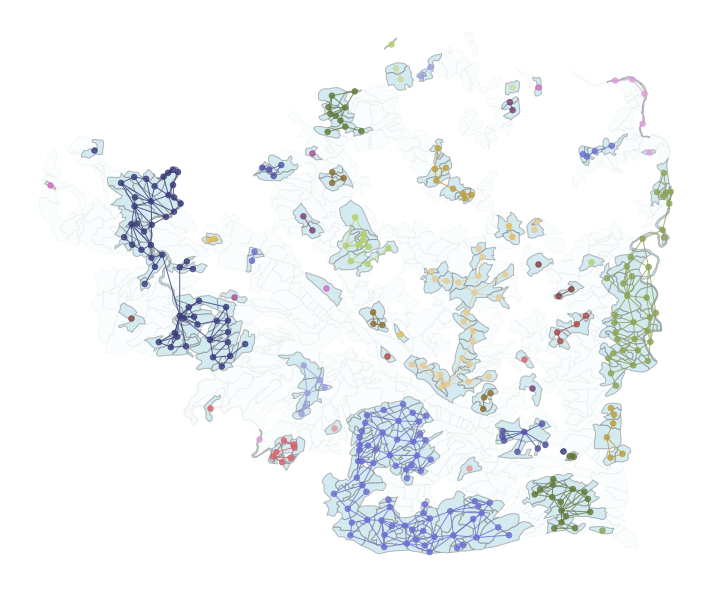

In [26]:
# Create a plot
fig, ax = plt.subplots(figsize=(10, 10))

# Background stands
stands_gdf.plot(ax=ax, color='lightblue', edgecolor='grey', alpha=0.05)

# Foreground stands
stands.plot(ax=ax, color='lightblue', edgecolor='grey', alpha=0.5)

# Colormap for 51 components
colors = plt.cm.get_cmap('tab20b', 51)  # e.g., tab20b supports more variety

# Node positions
pos = {node: (stand['geometry'].centroid.x, stand['geometry'].centroid.y) 
       for node, stand in G.nodes(data=True)}

# Draw each component
for comp_id, component in components_dict.items():
    color = colors(comp_id % 51)  # pick from the 51-color palette
    nx.draw(
        G.subgraph(component),
        pos,
        ax=ax,
        node_color=[color]*len(component),
        edge_color=[color]*len(G.subgraph(component).edges()),
        node_size=30,
        alpha=0.8,
        with_labels=False
    )

# Show the plot
plt.tight_layout()
plt.show()

## 🧩🧩 combine with ring of neighbors
1. dissolve inaccessible clusters into big inaccessible component
2. find ring of neighbors
3. store components including ring of neighbors

#### 🔎 find neighbors and put together with the components

In [27]:
## Initialize a dictionary to store all combined components
combi_components_dict = {}
combi_components_gdfs_dict = {}

gdf_of_combi_component_stands = gpd.GeoDataFrame()  # Initialize an empty GeoDataFrame

# Iterate over the components_dict
for c_id, component in components_dict.items():

    # Get the component and non-component GeoDataFrames
    component_gdf = stands[stands['ID_UG'].isin(component)].copy()
    non_component_gdf = stands_gdf[~stands_gdf['ID_UG'].isin(component)].copy()

    # Dissolve the inaccessible stands in the component into a single geometry
    dissolved_component_gdf = component_gdf.dissolve()

    # Apply a buffer, then find neighboring stands of the full component
    buffer_gdf = dissolved_component_gdf.copy()
    buffer_gdf['geometry'] = buffer_gdf.geometry.buffer(1.0)  # 1-meter buffer

    # Check if buffer_gdf has valid geometry before proceeding
    if not buffer_gdf.empty and buffer_gdf.geometry.notna().any():
        # Find neighboring stands using intersection with the buffer geometry
        neighbors_gdf = non_component_gdf[non_component_gdf.geometry.intersects(buffer_gdf.geometry.unary_union)].copy()
        neighbors_gdf['access'] = 'accessible'  # Mark accessibility for neighbors
        neighbors_gdf['component_id'] = c_id  # << Add component ID to neighbors
    else:
        print(f"Warning: No valid geometry after buffering for component {c_id}. Skipping neighbor finding.")
        neighbors_gdf = gpd.GeoDataFrame(columns=non_component_gdf.columns)  # Create an empty GeoDataFrame

    # Mark accessibility for the component
    component_gdf['access'] = 'inaccessible'
    component_gdf['component_id'] = c_id  # << Add component ID to inaccessible stands

    # Append to the combined GeoDataFrame
    gdf_of_combi_component_stands = pd.concat([gdf_of_combi_component_stands, component_gdf, neighbors_gdf], ignore_index=True)

    # Create a separate GeoDataFrame for this component
    comp_with_neighbors_gdf = pd.concat([component_gdf, neighbors_gdf], ignore_index=True)

    # Store in dictionary for later use
    combi_components_dict[f"{c_id}"] = set(comp_with_neighbors_gdf.ID_UG)
    combi_components_gdfs_dict[f"{c_id}"] = comp_with_neighbors_gdf

In [28]:
combi_components_dict

{'1': {837, 838, 1155},
 '2': {814,
  840,
  841,
  842,
  843,
  844,
  845,
  858,
  859,
  862,
  863,
  907,
  908,
  909,
  910,
  911,
  912,
  913,
  914,
  923,
  924,
  925,
  985,
  986,
  987,
  989,
  990,
  991,
  992,
  993,
  995,
  996,
  997,
  998,
  999,
  1004,
  1155,
  1156,
  1157,
  1158,
  1159,
  1160,
  1161,
  1162,
  1163,
  1166,
  1167,
  1168,
  1169,
  1170,
  1219,
  1221,
  1222,
  1224,
  1225,
  1319,
  1322,
  1323,
  1324,
  1328,
  1329,
  1330,
  1331,
  1333,
  1335,
  1337,
  1415,
  1504,
  1509,
  1511,
  1537,
  1557,
  1558,
  1559,
  1561,
  1562,
  1563,
  1565,
  1566,
  1572,
  1580,
  1581,
  1582,
  1583,
  1584},
 '3': {846, 847, 848, 849, 850, 1171, 1301, 1556},
 '4': {1097,
  1101,
  1109,
  1112,
  1113,
  1199,
  1200,
  1201,
  1202,
  1515,
  1518,
  1519,
  1520,
  1622},
 '5': {809,
  1068,
  1071,
  1072,
  1074,
  1075,
  1076,
  1077,
  1078,
  1079,
  1080,
  1081,
  1082,
  1083,
  1084,
  1085,
  1086,
  1087,
  1088,


In [29]:
combi_components_gdfs_dict

{'1':    OBJECTID  TARGET_FID  LandUse_1        Ocupacao  ID_UG              NOME  \
 0       129         759          1  PbPb_3_21_1_Pv    838  Castelo de Paiva   
 1       128         758          1  EcEc_3_10_2_Pv    837  Castelo de Paiva   
 2       345        1063          1  EcEc_5_10_2_Pv   1155  Castelo de Paiva   
 
       YY_correct    XX_Correct  Altitude  Declive  ...   Shape_Leng  \
 0  152924.882783 -21301.926649     197.0  13.6303  ...  1885.373441   
 1  153027.146729 -21569.125860     151.0  11.6688  ...  2076.935175   
 2  152564.848460 -21191.332768     151.0  11.6688  ...  4766.832503   
 
       Shape_Area  HBC   CH  CBD   CC road_acces  \
 0  101354.109932  2.9  0.0  0.0  0.0       none   
 1  170975.628174  2.9  0.0  0.0  0.0       full   
 2  242023.414980  2.9  0.0  0.0  0.0       full   
 
                                             geometry        access  \
 0  POLYGON ((-21074.919 153065.150, -21101.162 15...  inaccessible   
 1  POLYGON ((-21287.683 153143

In [30]:
# Create a summary GeoDataFrame with component ID and combined geometry
summary_data = []

for comp_id, ID_UGs in combi_components_dict.items():
    gdf = stands_gdf[stands_gdf.ID_UG.isin(ID_UGs)]
    # Combine geometries into one using unary_union
    combined_geometry = gdf.geometry.unary_union
    summary_data.append({'component_id': comp_id, 'geometry': combined_geometry})

# Convert to GeoDataFrame
gdf_of_combi_components = gpd.GeoDataFrame(summary_data, columns=['component_id', 'geometry'], crs=stands_gdf.crs)

In [31]:
gdf_of_combi_components

,component_id,geometry
0,1,"POLYGON ((-21173.708 152749.913, -21160.479 15..."
1,2,"POLYGON ((-19954.229 148220.111, -20044.017 14..."
2,3,"POLYGON ((-16390.729 151856.539, -16417.518 15..."
3,4,"POLYGON ((-12206.400 145818.778, -12278.264 14..."
4,5,"POLYGON ((-15842.081 144405.635, -15793.515 14..."
5,6,"POLYGON ((-9818.310 152694.776, -9871.227 1527..."
6,7,"POLYGON ((-17515.862 149805.830, -17506.150 14..."
7,8,"POLYGON ((-14037.172 154594.305, -13990.476 15..."
8,9,"POLYGON ((-16762.440 146619.753, -16811.624 14..."
9,10,"POLYGON ((-16662.292 153655.872, -16594.181 15..."


#### 👁️ visualize the new components (inaccessible + neighbors)

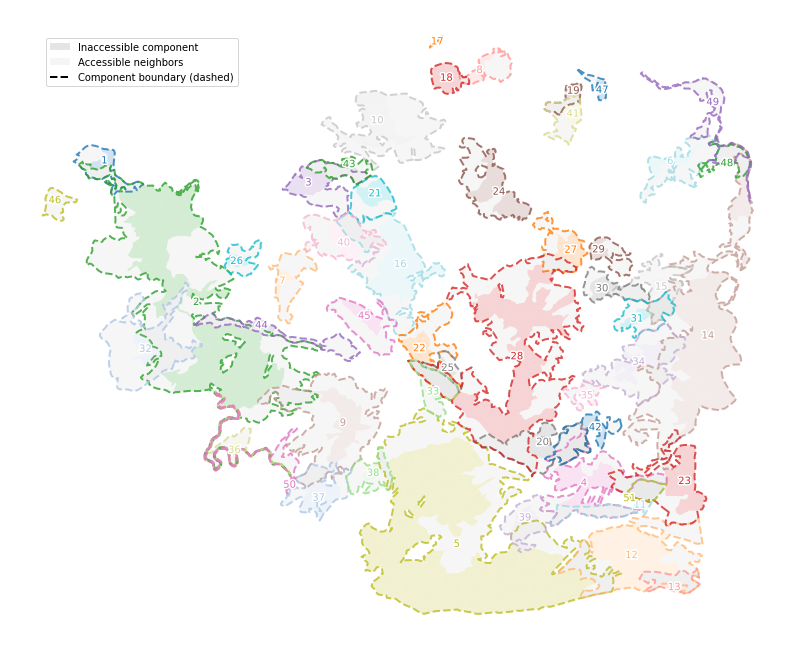

In [32]:
fig, ax = plt.subplots(figsize=(14, 14))

# colormap
num_components = len(combi_components_dict)
cmap = cm.get_cmap('tab20', num_components)
# Choose a step that spaces colors well; adjust 5 for desired spread
step = max(1, num_components // 5)
# Generate color indices by jumping in steps and wrap around with modulo
color_indices = [(i * step) % num_components for i in range(num_components)]
colors = [cmap(i) for i in color_indices]

# Accessible neighbors in light grey
gdf_of_combi_component_stands[gdf_of_combi_component_stands['access'] == 'accessible'].plot(
    ax=ax, color='lightgrey', edgecolor='none', alpha=0.2, label='Accessible neighbors')

for idx, (comp_id, comp_gdf) in enumerate(combi_components_gdfs_dict.items()):
    outline_color = colors[idx]
    outline_geom = comp_gdf.unary_union

    # Plot inaccessible stands filled with boundary color
    inacc = comp_gdf[comp_gdf['access'] == 'inaccessible']
    if not inacc.empty:
        inacc.plot(ax=ax, color=outline_color, edgecolor='none', alpha=0.2, hatch="")

    # Plot outline
    gpd.GeoSeries(outline_geom).plot(
        ax=ax, facecolor='none', edgecolor=outline_color, linestyle='--', linewidth=2, alpha=0.8
    )

    # Plot centroid point in same color as boundary (no black)
    if not inacc.empty:
        centroid = inacc.unary_union.centroid
        ax.plot(centroid.x, centroid.y, '', color='black', markersize=15, markeredgecolor='white', markeredgewidth=1.5)

        # Label in same color with white stroke for readability
        ax.text(
            centroid.x, centroid.y, comp_id,
            fontsize=10, ha='center', va='center',
            color=outline_color,
            path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
        )

legend_handles = [
    Patch(facecolor='grey', edgecolor='none', alpha=0.2, hatch='', label='Inaccessible component'),
    Patch(facecolor='lightgrey', edgecolor='none', alpha=0.2, label='Accessible neighbors'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Component boundary (dashed)')
]

ax.legend(handles=legend_handles, bbox_to_anchor=(0.05, 0.95), loc='upper left', borderaxespad=0.)
ax.set_axis_off()
plt.show()

#### 👁️ visualize the new components (inaccessible + neighbors)

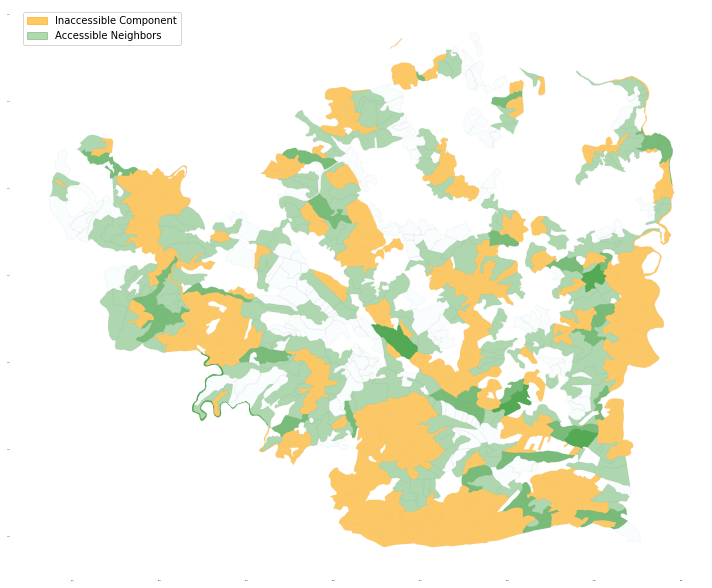

In [33]:
# Create a plot
fig, ax = plt.subplots(figsize=(10, 10))

# Background stands (all stands in very light blue)
stands_gdf.plot(ax=ax, color='lightblue', edgecolor='grey', alpha=0.05)

# Foreground stands (inaccessible
stands.plot(ax=ax, color='orange', edgecolor='none', alpha=0.6)

# Accessible neighbors in light grey
gdf_of_combi_component_stands[gdf_of_combi_component_stands['access'] == 'accessible'].plot(
    ax=ax, color='green', edgecolor='none', alpha=0.3, label='Accessible neighbors'
)

# Legend
handles = [
    #mpatches.Patch(color='lightblue', alpha=0.05, label='All Stands'),
    mpatches.Patch(color='orange', alpha=0.6, label='Inaccessible Component'),
    mpatches.Patch(color='green', alpha=0.3, label='Accessible Neighbors')
]
ax.legend(handles=handles, loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


### 💾 Save components including ring of neighbors

In [34]:
# Define the folder path
save_path = os.path.join(out_path, r'2_inaccessible_components_with_ring_of_accessible_neighbors')
os.makedirs(save_path, exist_ok=True)

# Now call the function once, passing the prepared components_dict
save_stands_shp_and_graph_png_per_component(save_path, stands_gdf, combi_components_dict, G)

store_components_csv(combi_components_dict, save_path, file_format='csv')

Saved 51 component lists and graphs to '1_Preprocessed_Data\3_Stand_Components\2_inaccessible_components_with_ring_of_accessible_neighbors'


## 🔗 find overlaps between newly created segments

### 🔎 find overlapping pairs

#### [helper functions] find overlapping pairs

In [35]:
combi_components_gdfs_dict

{'1':    OBJECTID  TARGET_FID  LandUse_1        Ocupacao  ID_UG              NOME  \
 0       129         759          1  PbPb_3_21_1_Pv    838  Castelo de Paiva   
 1       128         758          1  EcEc_3_10_2_Pv    837  Castelo de Paiva   
 2       345        1063          1  EcEc_5_10_2_Pv   1155  Castelo de Paiva   
 
       YY_correct    XX_Correct  Altitude  Declive  ...   Shape_Leng  \
 0  152924.882783 -21301.926649     197.0  13.6303  ...  1885.373441   
 1  153027.146729 -21569.125860     151.0  11.6688  ...  2076.935175   
 2  152564.848460 -21191.332768     151.0  11.6688  ...  4766.832503   
 
       Shape_Area  HBC   CH  CBD   CC road_acces  \
 0  101354.109932  2.9  0.0  0.0  0.0       none   
 1  170975.628174  2.9  0.0  0.0  0.0       full   
 2  242023.414980  2.9  0.0  0.0  0.0       full   
 
                                             geometry        access  \
 0  POLYGON ((-21074.919 153065.150, -21101.162 15...  inaccessible   
 1  POLYGON ((-21287.683 153143

In [36]:
def find_overlapping_component_pairs(dict_of_combicomponents_gdfs):
    """Step 1: Identify all overlapping component pairs."""
    overlapping_pairs = []
    checked_pairs = set()

    for id1, gdf1 in dict_of_combicomponents_gdfs.items():
        for id2, gdf2 in dict_of_combicomponents_gdfs.items():
            if id1 >= id2 or (id2, id1) in checked_pairs:
                continue

            geom1 = gdf1.unary_union
            geom2 = gdf2.unary_union

            if geom1.intersects(geom2):
                overlapping_pairs.append((id1, id2))

            checked_pairs.add((id1, id2))

    return overlapping_pairs

def build_stand_graph(all_combi_components, roads_gdf):
    """
    Build a graph where:
    - Nodes are individual stands (identified by (comp_id, row_index))
    - Edges exist if two stands touch and a connecting line between them does not intersect any road
    """
    G = nx.Graph()
    
    # Add all stands as nodes
    for comp_id, gdf in all_combi_components.items():
        for idx, row in gdf.iterrows():
            G.add_node((comp_id, idx), geometry=row.geometry, access=row['road_acces'])
    
    # Add edges between stands that touch and don't cross a road
    nodes = list(G.nodes(data=True))
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            geom1 = nodes[i][1]['geometry']
            geom2 = nodes[j][1]['geometry']
            
            # Must touch to be connected
            if not geom1.touches(geom2):
                continue
            
            # Line connecting centroids
            line = LineString([geom1.centroid, geom2.centroid])
            
            # Skip if line intersects any road
            if any(line.intersects(r.geometry) for _, r in roads_gdf.iterrows()):
                continue
            
            # Add edge
            G.add_edge(nodes[i][0], nodes[j][0])
    
    return G

def classify_overlaps_by_boundary_connectivity(overlapping_pairs, all_combi_components, roads_gdf):
    """
    Classify overlapping component pairs as same-side or opposite-side based on
    boundary connectivity along stands without crossing a road.
    """
    G = build_stand_graph(all_combi_components, roads_gdf)
    
    same_side_overlaps = []
    opposite_side_overlaps = []
    
    for id1, id2 in overlapping_pairs:
        # Get inaccessible stand nodes for each component
        cluster1_nodes = [(id1, idx) for idx, row in all_combi_components[id1].iterrows() if row['road_acces'] == 'none']
        cluster2_nodes = [(id2, idx) for idx, row in all_combi_components[id2].iterrows() if row['road_acces'] == 'none']
        
        if not cluster1_nodes or not cluster2_nodes:
            continue  # skip if no inaccessible stands
        
        # Check connectivity in graph
        connected = False
        for n1 in cluster1_nodes:
            for n2 in cluster2_nodes:
                if nx.has_path(G, n1, n2):
                    connected = True
                    break
            if connected:
                break
        
        if connected:
            same_side_overlaps.append((id1, id2))
        else:
            opposite_side_overlaps.append((id1, id2))
    
    return same_side_overlaps, opposite_side_overlaps

In [37]:
overlapping_pairs = find_overlapping_component_pairs(combi_components_gdfs_dict)
same_side_overlaps, opposite_side_overlaps = classify_overlaps_by_boundary_connectivity(
    overlapping_pairs, combi_components_gdfs_dict, roads_min3m
)

print(f"Same-side overlaps: {len(same_side_overlaps)}")
print(f"Opposite-side overlaps: {len(opposite_side_overlaps)}")

# Convert same-side overlaps to a set with frozensets for order-independent comparison
same_side_set = {frozenset(pair) for pair in same_side_overlaps}

# Filter opposite-side overlaps
opposite_side_overlaps = [pair for pair in opposite_side_overlaps if frozenset(pair) not in same_side_set]

# Optional: print results
print(f"Filtered opposite-side overlaps: {len(opposite_side_overlaps)}")

def remove_duplicate_pairs(pairs_list):
    seen = set()
    unique_pairs = []
    for id1, id2 in pairs_list:
        pair_set = frozenset([id1, id2])  # order-independent
        if pair_set not in seen:
            seen.add(pair_set)
            unique_pairs.append((id1, id2))
    return unique_pairs

# Remove duplicates from both lists
same_side_overlaps = remove_duplicate_pairs(same_side_overlaps)
opposite_side_overlaps = remove_duplicate_pairs(opposite_side_overlaps)

# Optional: print results
print(f"Same-side overlaps after removing duplicates: {len(same_side_overlaps)}")
print(f"Opposite-side overlaps after removing duplicates: {len(opposite_side_overlaps)}")


Same-side overlaps: 18
Opposite-side overlaps: 48
Filtered opposite-side overlaps: 48
Same-side overlaps after removing duplicates: 18
Opposite-side overlaps after removing duplicates: 48


### 👁 visualize overlaps

In [38]:
def plot_overlap_pairs_with_roads(overlap_pairs, all_combi_components, roads_gdf, title_prefix):
    for i, (id1, id2) in enumerate(overlap_pairs):
        fig, ax = plt.subplots(figsize=(8, 8))

        # Combine geometries of both components to get the bounding box
        gdf1 = all_combi_components[id1]
        gdf2 = all_combi_components[id2]
        combined_geom = gdf1.unary_union.union(gdf2.unary_union)
        minx, miny, maxx, maxy = combined_geom.bounds
        bbox_geom = box(minx, miny, maxx, maxy)

        # Plot components
        for gdf in [gdf1, gdf2]:
            # Inaccessible stands in orange
            inac = gdf[gdf['access'] == 'inaccessible']
            if not inac.empty:
                inac.plot(ax=ax, color='orange', alpha=0.6, edgecolor='none')

            # Accessible stands in green
            acc = gdf[gdf['access'] == 'accessible']
            if not acc.empty:
                acc.plot(ax=ax, color='green', alpha=0.4)

        # Plot roads that intersect the bounding box only
        roads_to_plot = roads_gdf[roads_gdf.intersects(bbox_geom)]
        if not roads_to_plot.empty:
            roads_to_plot.plot(ax=ax, color='black', linewidth=2)

        # Set title with component IDs
        ax.set_aspect("equal")

        # SET TITLE LAST
        ax.set_title(f"{title_prefix}: {id1} – {id2}", fontsize=12)
        plt.show()


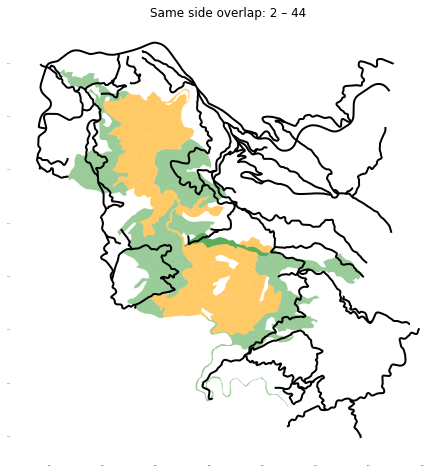

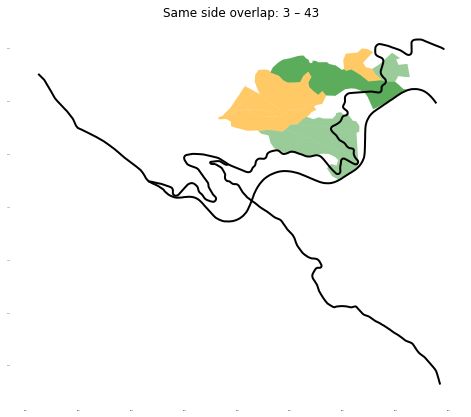

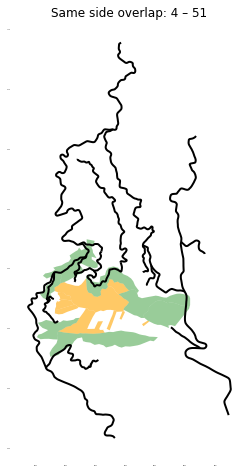

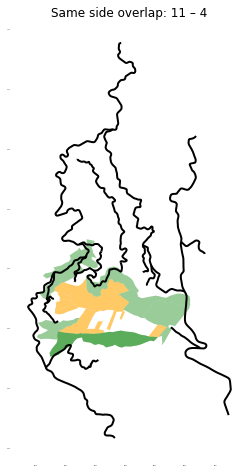

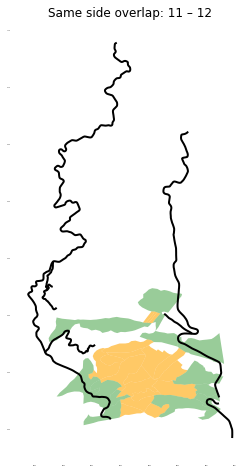

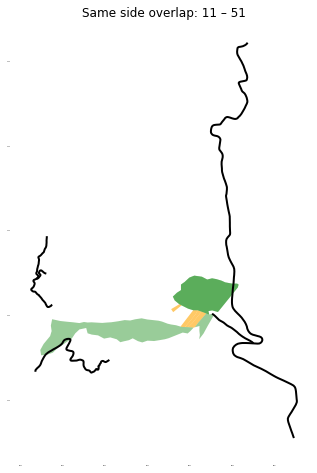

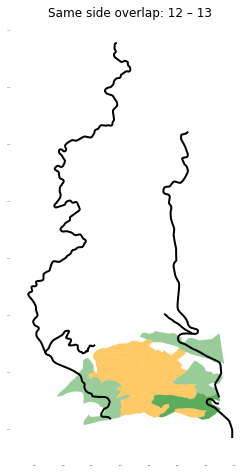

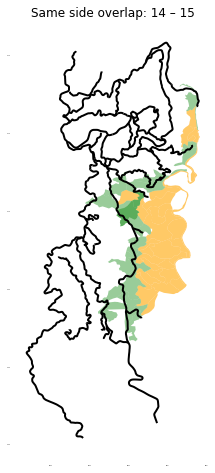

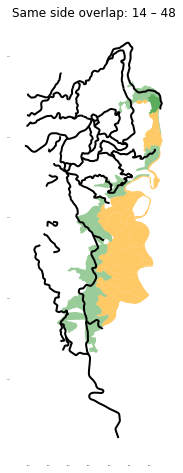

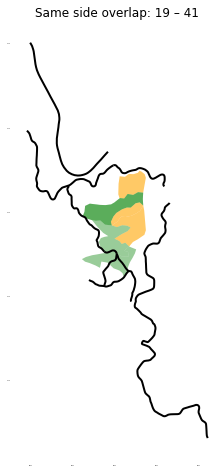

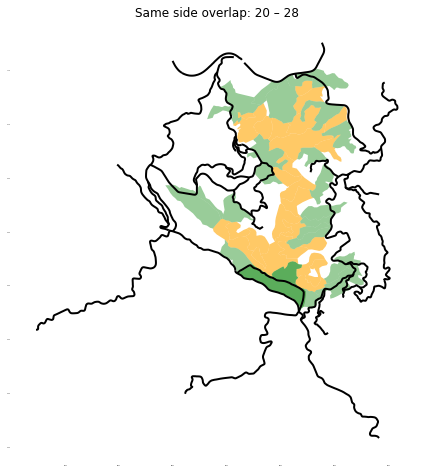

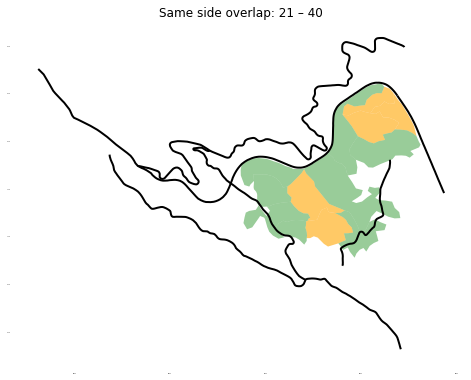

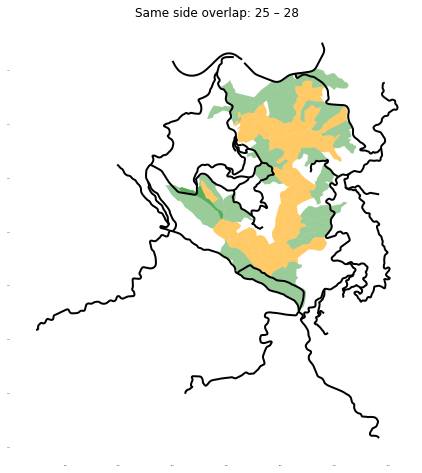

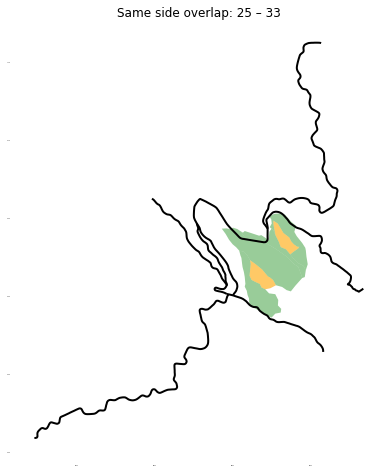

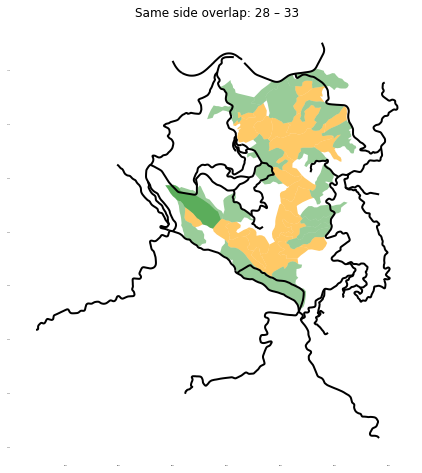

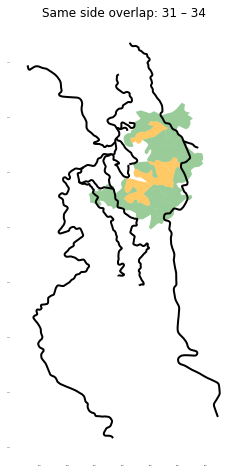

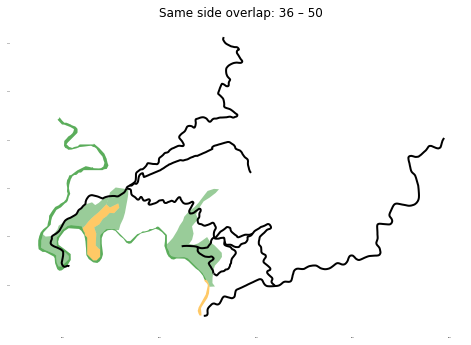

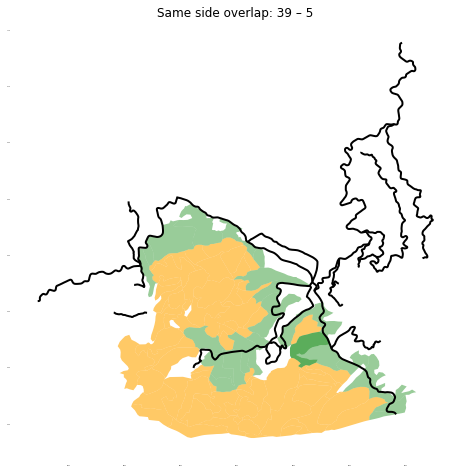

In [39]:
plot_overlap_pairs_with_roads(same_side_overlaps, combi_components_gdfs_dict, roads_min3m, title_prefix="Same side overlap")

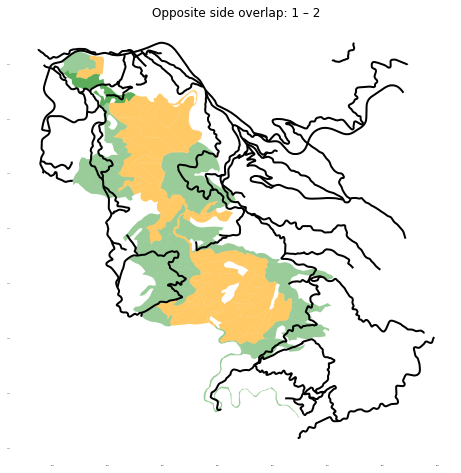

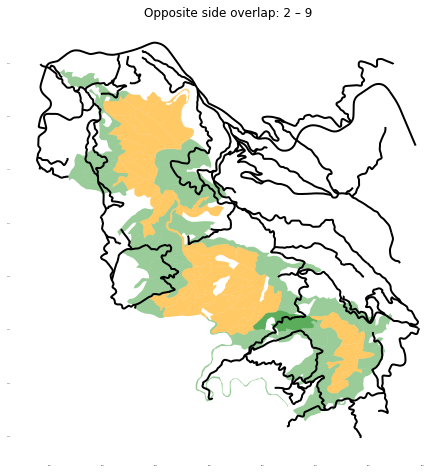

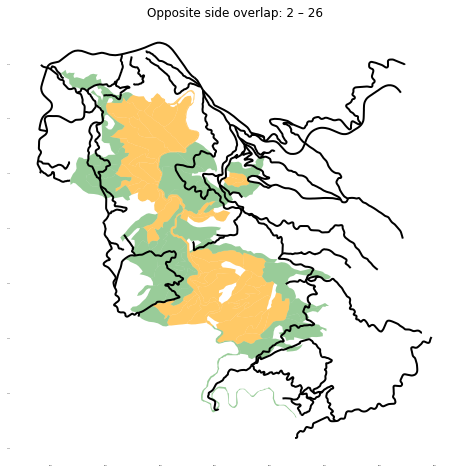

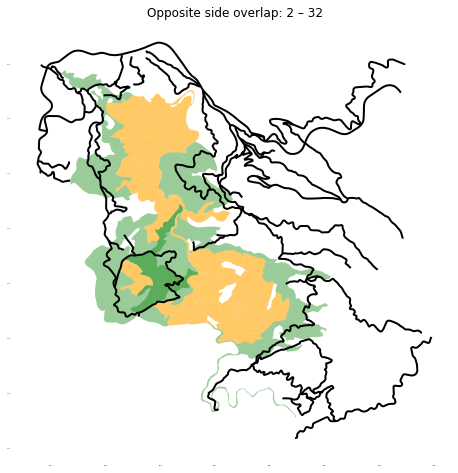

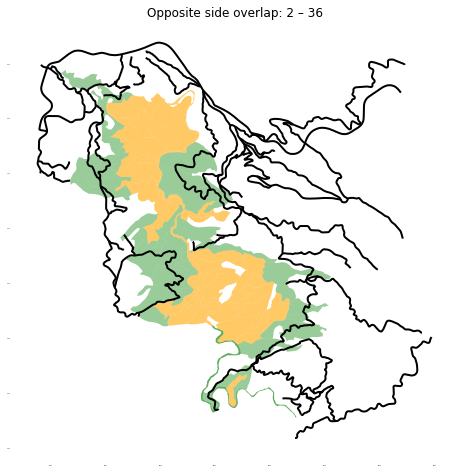

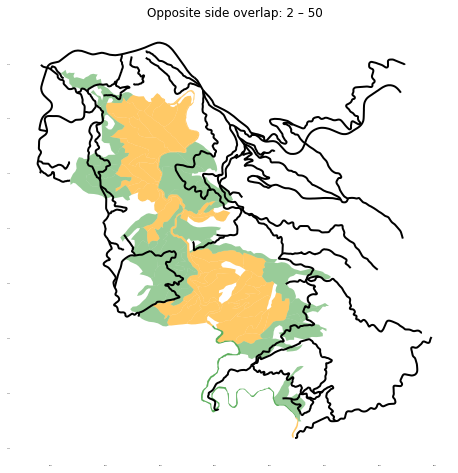

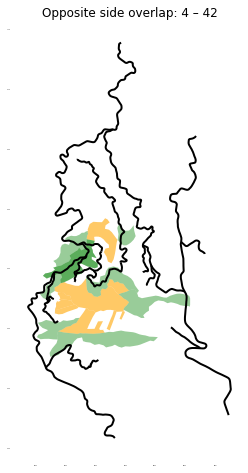

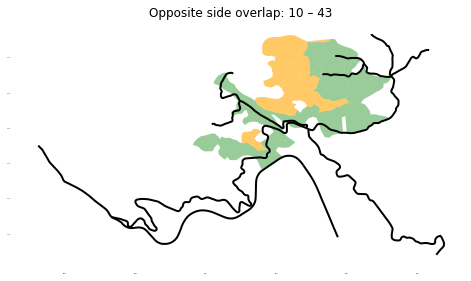

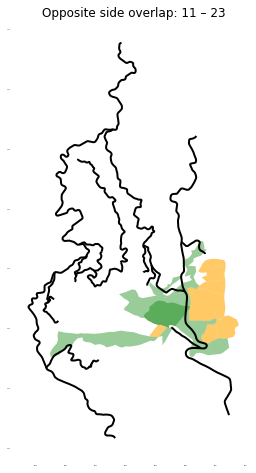

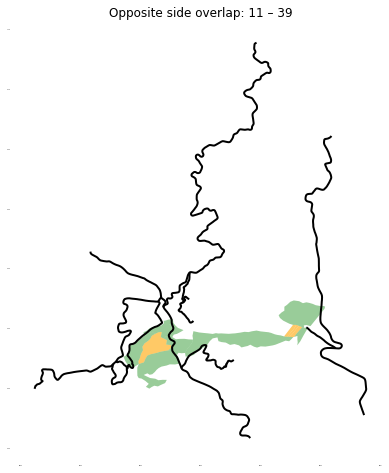

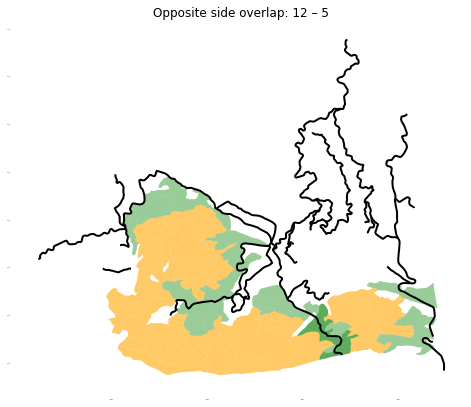

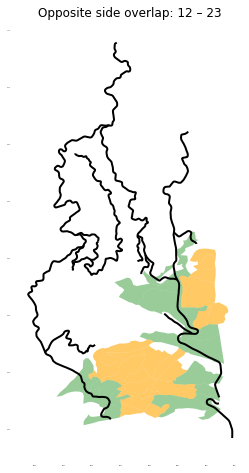

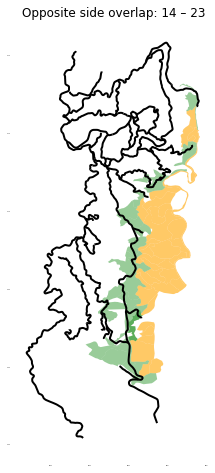

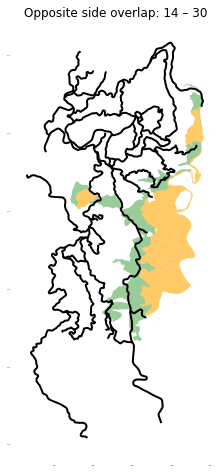

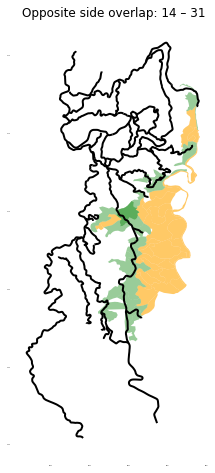

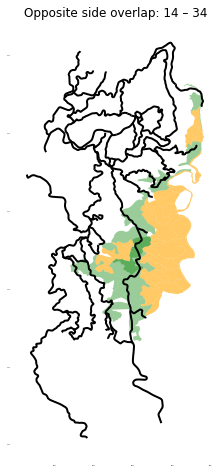

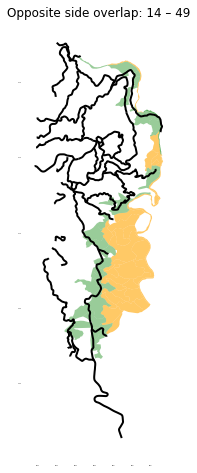

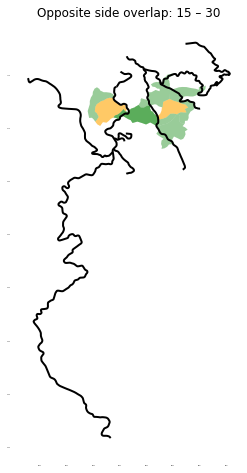

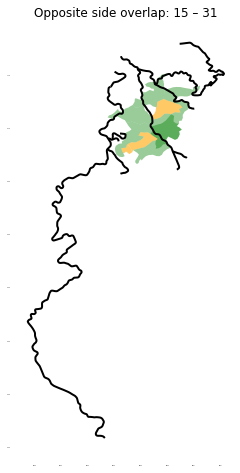

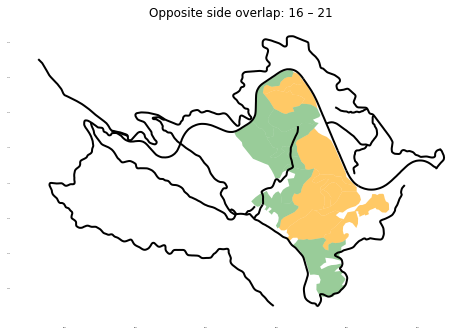

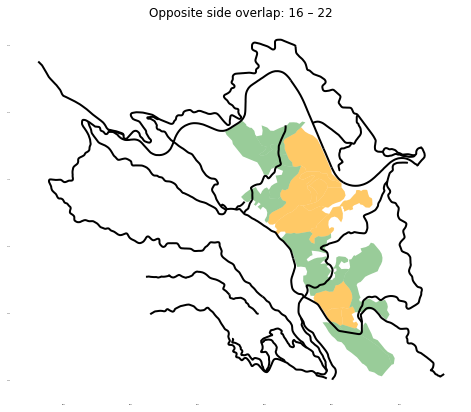

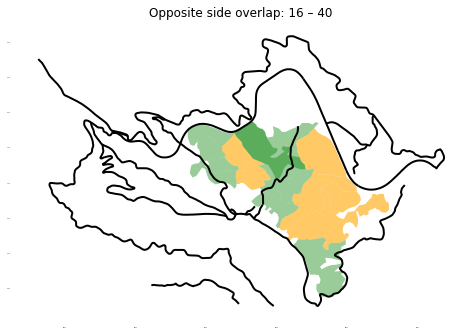

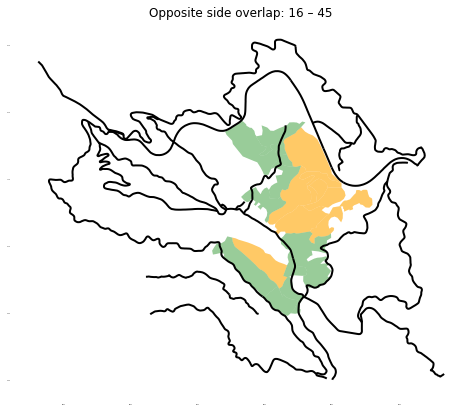

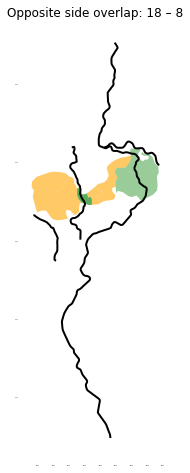

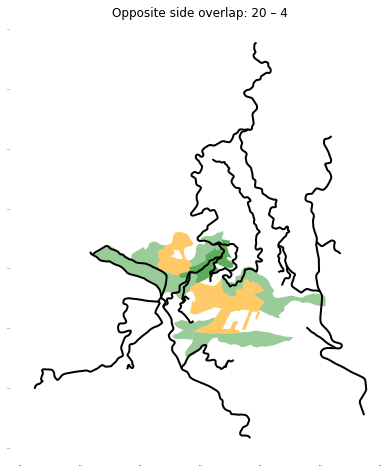

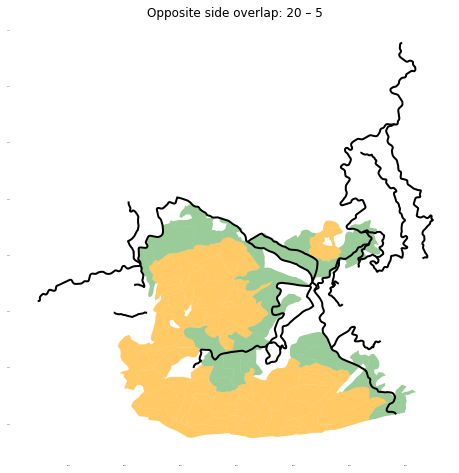

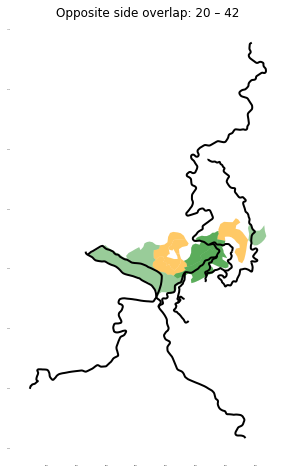

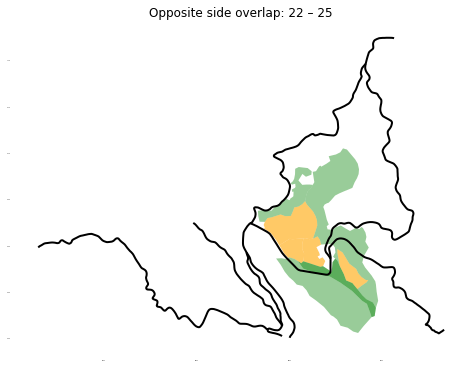

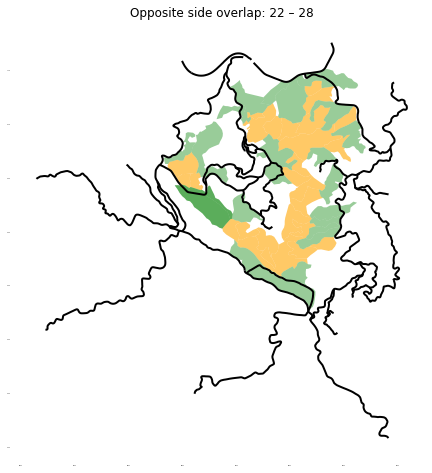

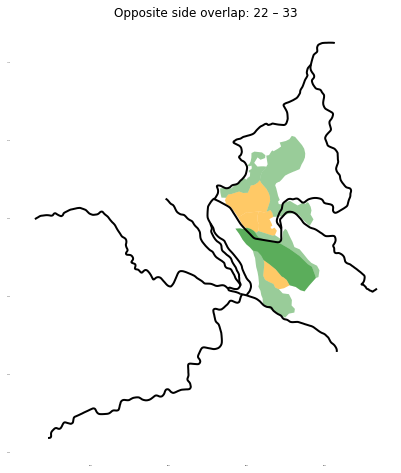

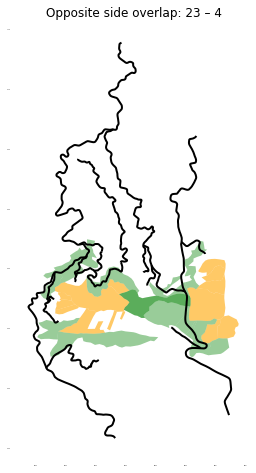

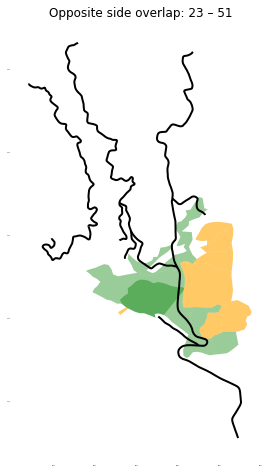

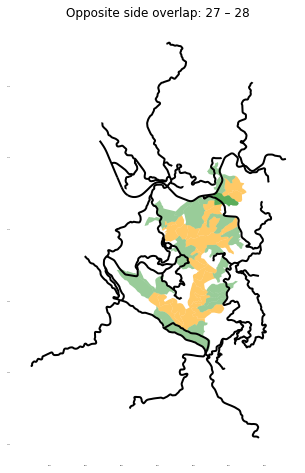

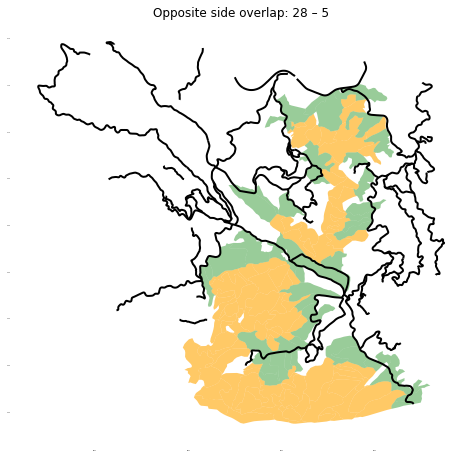

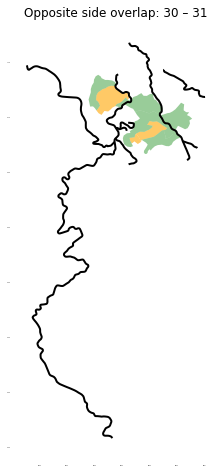

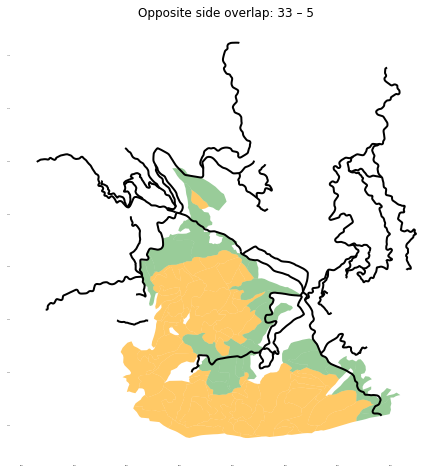

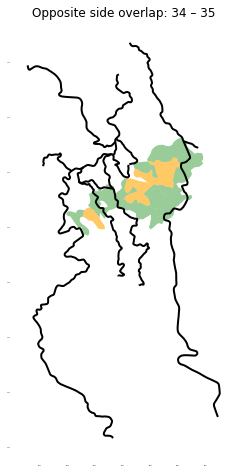

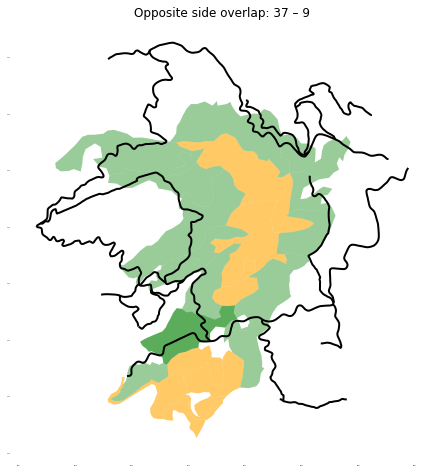

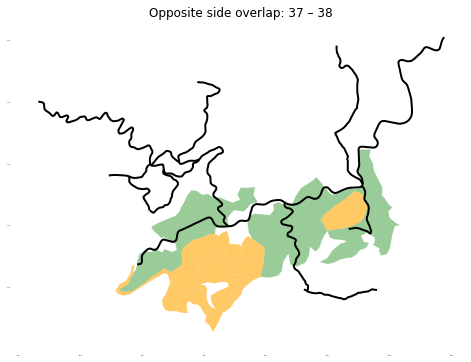

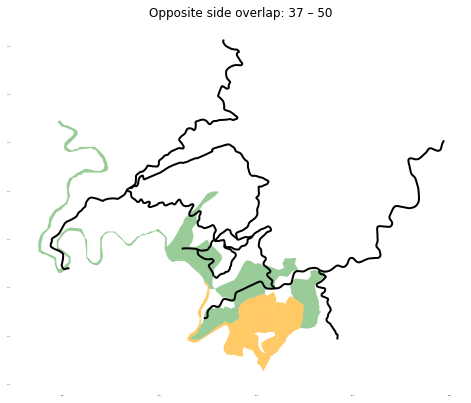

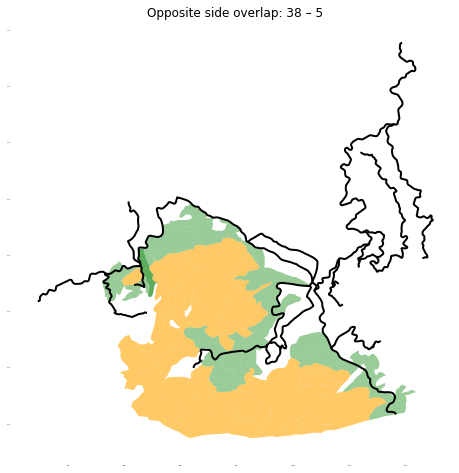

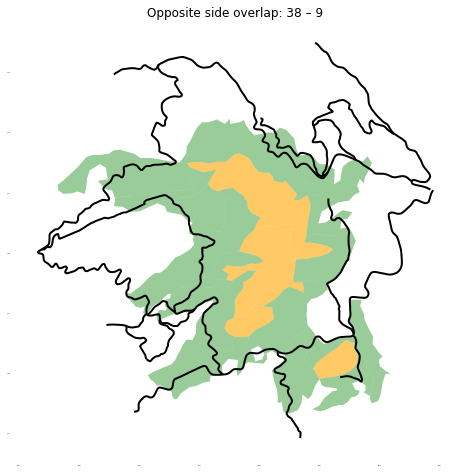

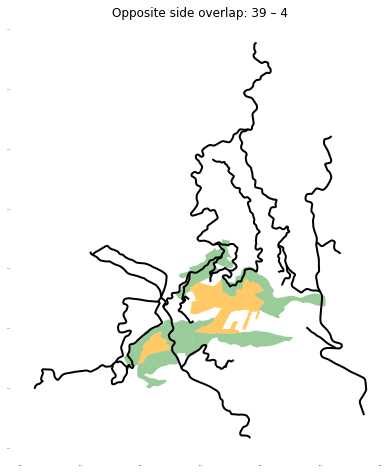

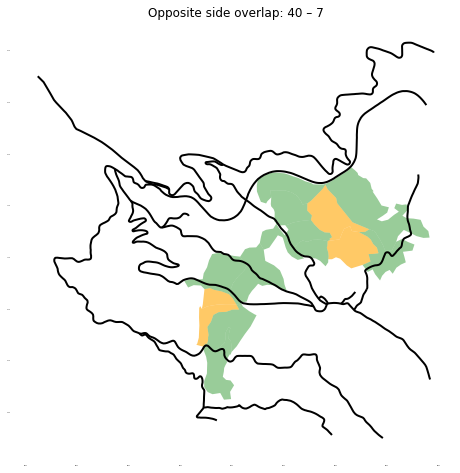

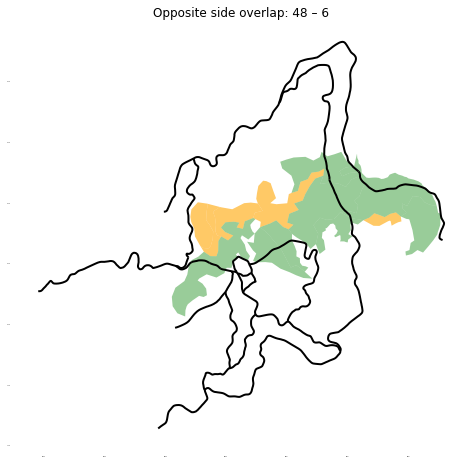

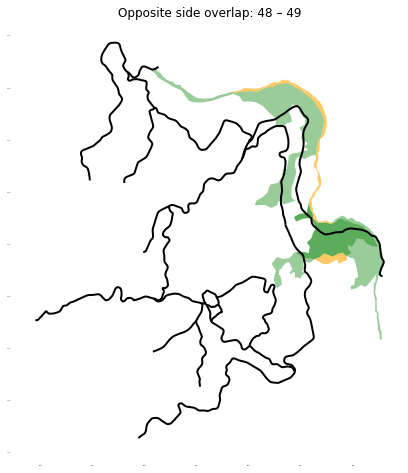

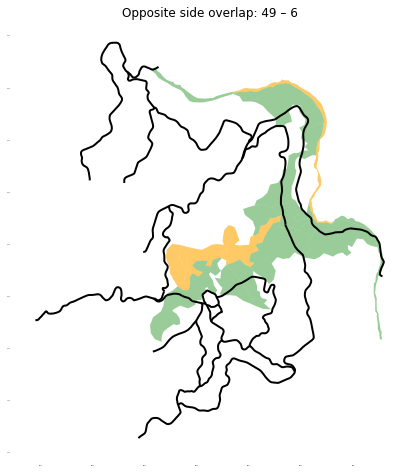

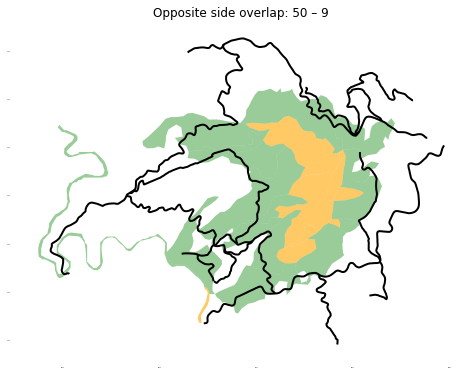

In [40]:
plot_overlap_pairs_with_roads(opposite_side_overlaps, combi_components_gdfs_dict, roads_min3m, title_prefix="Opposite side overlap")

## 🔗 merge overlaps

In [41]:
def group_overlapping_components(overlapping_pairs):
    """
    Group connected components using a graph from given pairs.
    Each connected component in the graph represents a group of overlapping components.
    """
    G = nx.Graph()
    G.add_edges_from(overlapping_pairs)
    connected_components = list(nx.connected_components(G))
    return connected_components

In [42]:
# Perform the merge of overlapping components for same side overlaps

# Step 1: Group components, using only same-side overlaps (returns a dict)
connected_components = group_overlapping_components(same_side_overlaps)

# make the dict key an integer
connected_components = [
    {int(cid) for cid in group}
    for group in connected_components
]

# prep empty dicted to store the merged components
merged_components_dict = {}

# loop over the groups created in step 1
for group in connected_components:
    print("Group:", group)

    # Merge all ID_UGs in this group
    merged_id_ugs = set()
    for comp_id in group:
        merged_id_ugs |= combi_components_dict[str(comp_id)]
    
    # Create a merged component name
    merged_name = "_".join(map(str, sorted(group))) + "_merged"
    
    merged_components_dict[merged_name] = merged_id_ugs

# Step 3: Print results
print(f'{len(merged_components_dict)} merged components from same-side overlaps')
for name, standsIDs in merged_components_dict.items():
    print(name, standsIDs)

Group: {2, 44}
Group: {3, 43}
Group: {4, 11, 12, 13, 51}
Group: {48, 14, 15}
Group: {41, 19}
Group: {25, 20, 28, 33}
Group: {40, 21}
Group: {34, 31}
Group: {50, 36}
Group: {5, 39}
10 merged components from same-side overlaps
2_44_merged {1537, 1557, 1558, 1559, 1561, 1562, 1563, 1565, 1566, 1572, 1319, 1320, 1322, 1323, 1580, 1581, 1582, 1583, 1584, 1324, 814, 1328, 1329, 1330, 1331, 1333, 1335, 1337, 840, 841, 842, 843, 844, 845, 858, 859, 862, 863, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1415, 907, 1166, 1167, 1168, 1169, 1170, 908, 909, 910, 911, 912, 913, 914, 1174, 923, 924, 925, 1219, 1221, 1222, 1224, 1225, 985, 986, 987, 989, 990, 991, 992, 993, 1504, 995, 996, 997, 998, 1511, 999, 1509, 1004}
3_43_merged {846, 847, 848, 849, 850, 1171, 1556, 1301, 1299, 820}
4_11_12_13_51_merged {1152, 1153, 1292, 1199, 1200, 1201, 1202, 1203, 1212, 1213, 1097, 1101, 1490, 1109, 1622, 1493, 1112, 1113, 1494, 1497, 1623, 867, 868, 869, 870, 871, 872, 873, 874, 1515, 1258, 1259, 15

### Prepare dicts with all final component (one with stand IDs, one with Polygons)

In [43]:
# Step 1: Collect all component IDs involved in any merge group
merged_comp_ids = set().union(*connected_components) if connected_components else set()
merged_comp_ids = {str(a) for a in merged_comp_ids}

# Step 2: Identify untouched component IDs
all_comp_ids = set(combi_components_dict.keys())

# remove the merged IDs from the set of all IDs to get the untouched comp IDs
untouched_comp_ids = all_comp_ids - merged_comp_ids
untouched_comp_ids = sorted(untouched_comp_ids, key=int)

# Step 3: Create separate dicts for untouched components (comp ID: polygon)
untouched_components_gdfs_dict = {
    comp_id: shape(combi_components_gdfs_dict[comp_id].unary_union)
    for comp_id in untouched_comp_ids
}

# dict (comp ID: stand IDs)
untouched_components_dict = {
    comp_id: item
    for comp_id, item in combi_components_dict.items()
    if comp_id in untouched_comp_ids
}

# and a dict for merged components (comp ID: gdf)
merged_components_geom_dict = {
    cid: stands_gdf.loc[
        stands_gdf["ID_UG"].isin(id_ug_set),
        "geometry"
    ].unary_union
    for cid, id_ug_set in merged_components_dict.items()
}

# Step 5: Combine the dict of untouched comps with dict of merged components
final_components_dict = {**merged_components_dict, **untouched_components_dict}
final_components_geom_dict = {**merged_components_geom_dict, **untouched_components_gdfs_dict}

#### prepare gdf for plotting

In [44]:
# Step 5: Convert to GeoDataFrame (compID, comp geometry)
final_components_gdf = gpd.GeoDataFrame(
    {'id': list(final_components_geom_dict.keys())},
    geometry=list(final_components_geom_dict.values()),
    crs=stands_gdf.crs
)
print(final_components_gdf)

# same for the merged ones, for plotting later
merged_components_gdf = gpd.GeoDataFrame(
    {'id': list(merged_components_geom_dict.keys())},
    geometry=list(merged_components_geom_dict.values()),
    crs=stands_gdf.crs
)

                      id                                           geometry
0            2_44_merged  POLYGON ((-19954.229 148220.111, -20044.017 14...
1            3_43_merged  POLYGON ((-16390.729 151856.539, -16417.518 15...
2   4_11_12_13_51_merged  MULTIPOLYGON (((-11274.137 144152.733, -11394....
3        14_15_48_merged  POLYGON ((-9804.113 147197.280, -9867.987 1471...
4           19_41_merged  POLYGON ((-11831.191 153584.828, -11751.660 15...
5     20_25_28_33_merged  POLYGON ((-12672.402 147400.559, -12672.128 14...
6           21_40_merged  POLYGON ((-16647.215 150963.118, -16688.700 15...
7           31_34_merged  POLYGON ((-10445.205 147994.288, -10493.830 14...
8           36_50_merged  POLYGON ((-17604.568 146251.062, -17599.664 14...
9            5_39_merged  POLYGON ((-15842.081 144405.635, -15793.515 14...
10                     1  POLYGON ((-21173.708 152749.913, -21160.479 15...
11                     6  POLYGON ((-9818.310 152694.776, -9871.227 1527...
12          

### 👁 visualize after merging

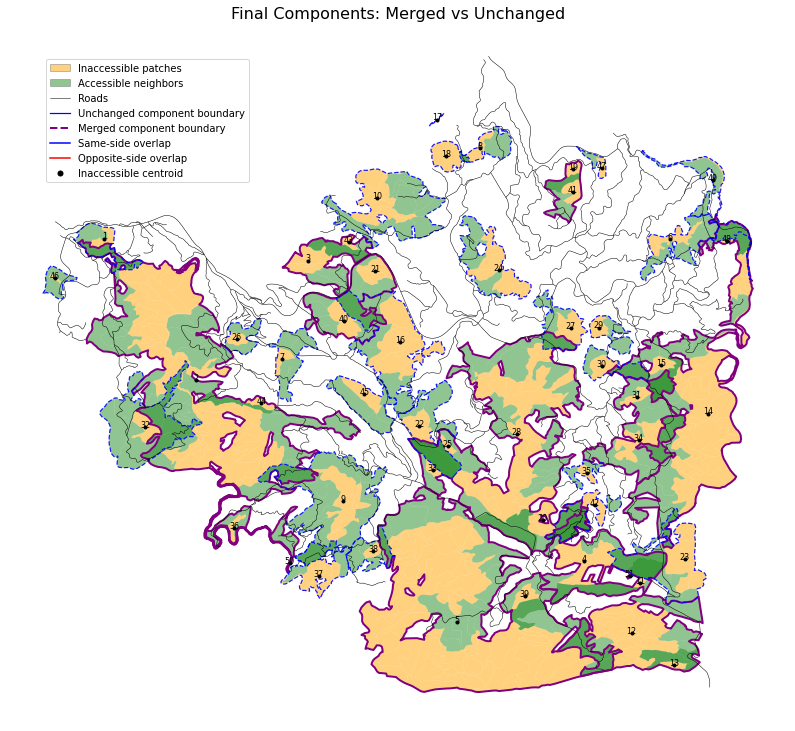

In [45]:
fig, ax = plt.subplots(figsize=(14, 14))

# Background roads
roads_min3m.plot(ax=ax, color='black', linewidth=0.5, label='Roads', alpha=1)

# Stand layers
gdf_of_combi_component_stands[gdf_of_combi_component_stands['access'] == 'inaccessible'].plot(ax=ax, color='orange', edgecolor='none', alpha=0.5)
gdf_of_combi_component_stands[gdf_of_combi_component_stands['access'] == 'accessible'].plot(ax=ax, color='forestgreen', edgecolor='none', alpha=0.5)

# Optional: Plot component centroids
for comp_id, gdf in combi_components_gdfs_dict.items():
    inacc = gdf[gdf['access'] == 'inaccessible']
    if not inacc.empty:
        centroid = inacc.unary_union.centroid
        ax.plot(centroid.x, centroid.y, 'ko', markersize=3)
        ax.text(centroid.x, centroid.y, comp_id, fontsize=8, ha='center', color='black')

# Plot merged component boundaries (dashed purple)
merged_components_gdf.plot(ax=ax, facecolor='none', edgecolor='purple', linestyle='-', linewidth=2, alpha=1)

# Plot untouched (unmerged) component boundaries (solid blue)
untouched_gdf = final_components_gdf[~final_components_gdf['id'].isin(merged_components_gdf['id'])]
untouched_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linestyle='--', linewidth=1.2, alpha=0.9)

# Build legend
legend_handles = [
    Patch(facecolor='orange', edgecolor='grey', label='Inaccessible patches', alpha=0.5),
    Patch(facecolor='forestgreen', edgecolor='grey', label='Accessible neighbors', alpha=0.5),
    Line2D([0], [0], color='black', lw=0.5, label='Roads', alpha=1),
    Line2D([0], [0], color='blue', lw=1.2, label='Unchanged component boundary'),
    Line2D([0], [0], color='purple', lw=2, linestyle='--', label='Merged component boundary'),
    Line2D([0], [0], color='blue', lw=1.5, label='Same-side overlap'),
    Line2D([0], [0], color='red', lw=1.5, label='Opposite-side overlap'),
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='Inaccessible centroid', markersize=5)
]

# Display legend
ax.legend(handles=legend_handles, bbox_to_anchor=(0.05, 0.95), loc='upper left', borderaxespad=0.)
ax.set_axis_off()
plt.title("Final Components: Merged vs Unchanged", fontsize=16)
plt.savefig("final_component_boundaries_merged_unmerged.png", bbox_inches='tight')
plt.show()

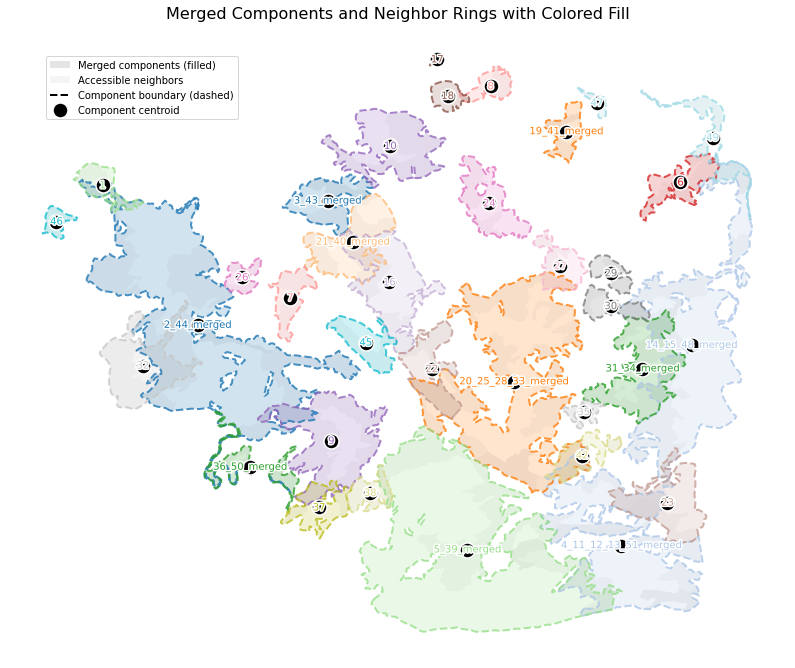

In [46]:
fig, ax = plt.subplots(figsize=(14, 14))

# Accessible neighbors in light grey (same as before)
gdf_of_combi_component_stands[gdf_of_combi_component_stands['access'] == 'accessible'].plot(
    ax=ax, color='lightgrey', edgecolor='none', alpha=0.2, label='Accessible neighbors'
)

num_components = len(final_components_gdf)
color_map = cm.get_cmap('tab20', num_components)
colors = [color_map(i) for i in range(num_components)]

for idx, row in final_components_gdf.iterrows():
    comp_id = row['id']
    geom = row.geometry
    
    outline_color = colors[idx]

    # Separate inaccessible and accessible parts are not directly available here, 
    # so we’ll just fill the merged component geometry lightly
    # with outline color, no hatching
    gpd.GeoSeries([geom]).plot(
        ax=ax, color=outline_color, edgecolor='none', alpha=0.2
    )

    # Plot outline with dashed line
    gpd.GeoSeries([geom]).boundary.plot(
        ax=ax, color=outline_color, linestyle='--', linewidth=2, alpha=0.8
    )

    # Plot centroid point in black with white edge (as before)
    centroid = geom.centroid
    ax.plot(centroid.x, centroid.y, 'o', color='black', markersize=15, 
            markeredgecolor='white', markeredgewidth=1.5)

    # Label in outline color with white stroke for readability
    ax.text(
        centroid.x, centroid.y, comp_id,
        fontsize=10, ha='center', va='center',
        color=outline_color,
        path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
    )

# Legend matching the merged components plot style
legend_handles = [
    Patch(facecolor='grey', edgecolor='none', alpha=0.2, label='Merged components (filled)'),
    Patch(facecolor='lightgrey', edgecolor='none', alpha=0.2, label='Accessible neighbors'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Component boundary (dashed)'),
    Line2D([0], [0], marker='o', color='black', markerfacecolor='black', markeredgecolor='white',
           markeredgewidth=1.5, linestyle='None', markersize=15, label='Component centroid')
]

ax.legend(handles=legend_handles, bbox_to_anchor=(0.05, 0.95), loc='upper left', borderaxespad=0.)
ax.set_axis_off()
plt.title("Merged Components and Neighbor Rings with Colored Fill", fontsize=16)
plt.savefig("merged_components_neighbors_inaccessible_color.png", bbox_inches='tight')
plt.show()


## 💾 save the merged components

In [47]:
# Step 1: Ensure output directory exists
output_folder = os.path.join(out_path, "3_merged_components")
os.makedirs(output_folder, exist_ok=True)

In [48]:
save_stands_shp_and_graph_png_per_component(
    out_path=output_folder, 
    stands_gdf=stands_gdf, 
    components_dict=final_components_dict,
    G=G
)

Saved 35 component lists and graphs to '1_Preprocessed_Data\3_Stand_Components\3_merged_components'


## 👁️ visualize final problem segmentation to verify results

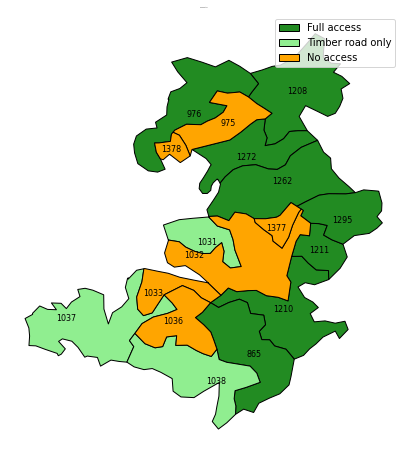

In [49]:
# example plot
gdf = gpd.read_file(
    r'1_Preprocessed_Data\3_Stand_Components\3_merged_components\comp_31_34_merged_stands.shp'
)

fig, ax = plt.subplots(figsize=(8, 8))

# Plot by road access
gdf[gdf['road_acces'] == 'full'].plot(
    ax=ax, color='forestgreen', edgecolor='black'
)
gdf[gdf['road_acces'] == 'timber'].plot(
    ax=ax, color='lightgreen', edgecolor='black'
)
gdf[gdf['road_acces'] == 'none'].plot(
    ax=ax, color='orange', edgecolor='black'
)

# Labels
for _, row in gdf.iterrows():
    centroid = row.geometry.representative_point()
    ax.text(
        centroid.x, centroid.y,
        str(row["ID_UG"]),
        fontsize=8,
        ha='center', va='center'
    )

# Title
ax.set_title(f"Component 27")
ax.axis('off')

# ---- Manual legend ----
legend_elements = [
    Patch(facecolor='forestgreen', edgecolor='black', label='Full access'),
    Patch(facecolor='lightgreen', edgecolor='black', label='Timber road only'),
    Patch(facecolor='orange', edgecolor='black', label='No access'),
]

ax.legend(handles=legend_elements, loc='best')

plt.show()

## create plots of segmentation for thesis report

In [51]:
# Directory containing the shapefiles
shapefile_dir = r'1_Preprocessed_Data\3_Stand_Components\3_merged_components'
output_dir = os.path.join(shapefile_dir, "4_segmentation_plots")

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Loop through all shapefiles in the directory
for filename in os.listdir(shapefile_dir):
    if not filename.endswith('.shp'):
        continue

    filepath = os.path.join(shapefile_dir, filename)

    # Load component shapefile
    gdf = gpd.read_file(filepath)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Background: all stands
    stands_gdf.plot(
        ax=ax,
        color='lightblue',
        alpha=0.25,
        edgecolor='none'
    )

    # Component stands colored by access type
    gdf[gdf['road_acces'] == 'full'].plot(
        ax=ax, color='forestgreen', edgecolor='none'
    )
    gdf[gdf['road_acces'] == 'timber'].plot(
        ax=ax, color='lightgreen', edgecolor='none'
    )
    gdf[gdf['road_acces'] == 'none'].plot(
        ax=ax, color='orange', edgecolor='none'
    )

    # Roads
    roads_min3m.plot(
        ax=ax, color='black', linewidth=0.5, alpha=1
    )

    # Title
    comp_id = gdf.iloc[0]["comp_id"] if "comp_id" in gdf.columns else filename.replace('.shp', '')
    ax.set_title(f"Component: {comp_id}")

    ax.axis('off')
    plt.tight_layout()

    # ---- Manual legend (only show present categories) ----
    present = gdf.road_acces.unique()
    legend_elements = []

    if 'full' in present:
        legend_elements.append(Patch(facecolor='forestgreen', edgecolor='black', label='Full access'))
    if 'timber' in present:
        legend_elements.append(Patch(facecolor='lightgreen', edgecolor='black', label='Road < 6m'))
    if 'none' in present:
        legend_elements.append(Patch(facecolor='orange', edgecolor='black', label='No access'))

    ax.legend(handles=legend_elements, loc='best')

    # Save plot
    fname = os.path.splitext(filename)[0]
    fname = fname.removesuffix("_stands")

    save_filepath = os.path.join(output_dir, f"{fname}_plot.png")

    plt.savefig(save_filepath, dpi=300, bbox_inches='tight')
    plt.close()

print('plots done')

c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(
c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(
c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(
c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(
c:\Users\johan\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\plotting.py:695: UserWarning: The GeoDataFrame you are attempting to 

plots done
